In [1]:
!pip install pandas numpy matplotlib scikit-learn statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.arima.model import ARIMA

In [3]:
# Load the dataset
df = pd.read_csv("sales_data.csv")

# Display the first five records
print(df.head())

# Display column names
print(df.columns)

# Identify independent and dependent variables
X = df[["advertising"]]
y = df["sales"]

print("Independent Variable: Advertising")
print("Dependent Variable: Sales")

# Check missing values
print(df.isnull().sum())

   advertising  sales
0           10     25
1           15     30
2           20     38
3           25     42
4           30     48
Index(['advertising', 'sales'], dtype='str')
Independent Variable: Advertising
Dependent Variable: Sales
advertising    0
sales          0
dtype: int64


In [4]:
df = df.dropna(subset=["advertising", "sales"])

X = df[["advertising"]]
y = df["sales"]


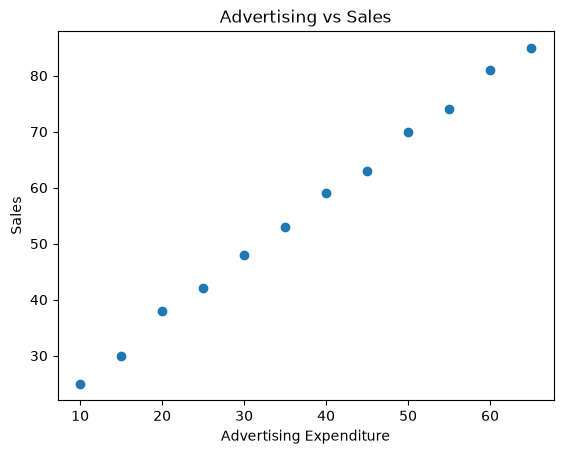

In [5]:
plt.scatter(df["advertising"], df["sales"])

plt.xlabel("Advertising Expenditure")
plt.ylabel("Sales")
plt.title("Advertising vs Sales")
plt.show()

In [6]:
# Create and train the model
model = LinearRegression()
model.fit(X, y)

# Display the regression equation
b0 = model.intercept_
b1 = model.coef_[0]

print("Intercept:", b0)
print("Slope:", b1)
print("Regression Equation: Sales =", b0, "+", b1, "* Advertising")

Intercept: 14.705128205128226
Slope: 1.0923076923076918
Regression Equation: Sales = 14.705128205128226 + 1.0923076923076918 * Advertising


In [7]:
advertising_value = pd.DataFrame({"advertising": [50]})

predicted_sales = model.predict(advertising_value)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 69.32051282051282


In [8]:
# Predict sales for all records
y_pred = model.predict(X)

# Calculate R2 score
r2 = r2_score(y, y_pred)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)

R2 Score: 0.998313669479218
Mean Squared Error: 0.6004273504273502


In [9]:
comparison = pd.DataFrame({
    "Actual Sales": y,
    "Predicted Sales": y_pred
})

print(comparison)

    Actual Sales  Predicted Sales
0             25        25.628205
1             30        31.089744
2             38        36.551282
3             42        42.012821
4             48        47.474359
5             53        52.935897
6             59        58.397436
7             63        63.858974
8             70        69.320513
9             74        74.782051
10            81        80.243590
11            85        85.705128


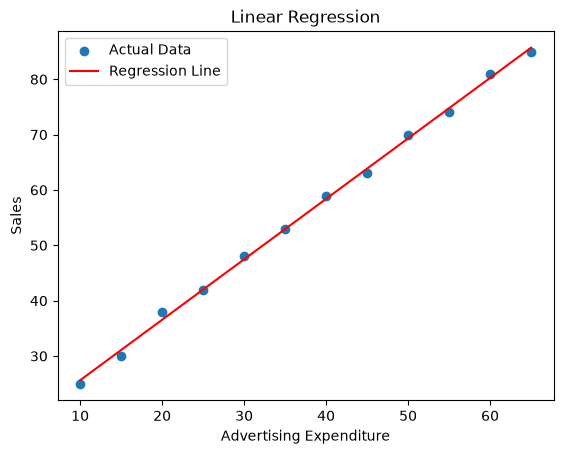

In [10]:
plt.scatter(X["advertising"], y, label="Actual Data")

plt.plot(X["advertising"], y_pred, color="red",
         label="Regression Line")

plt.xlabel("Advertising Expenditure")
plt.ylabel("Sales")
plt.title("Linear Regression")
plt.legend()
plt.show()

In [11]:
ts_df = pd.read_csv("monthly_sales.csv")

print(ts_df.head())

  Month  Sales
0   Jan    120
1   Feb    135
2   Mar    128
3   Apr    145
4   May    150


In [12]:
ts_df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    "Sales": [120, 135, 128, 145, 150, 160,
              155, 170, 165, 180, 190, 200]
})

print(ts_df)

   Month  Sales
0    Jan    120
1    Feb    135
2    Mar    128
3    Apr    145
4    May    150
5    Jun    160
6    Jul    155
7    Aug    170
8    Sep    165
9    Oct    180
10   Nov    190
11   Dec    200


In [13]:
ts_df["Date"] = pd.date_range(
    start="2025-01-01",
    periods=len(ts_df),
    freq="MS"
)

ts_df = ts_df.set_index("Date")

print(ts_df)

           Month  Sales
Date                   
2025-01-01   Jan    120
2025-02-01   Feb    135
2025-03-01   Mar    128
2025-04-01   Apr    145
2025-05-01   May    150
2025-06-01   Jun    160
2025-07-01   Jul    155
2025-08-01   Aug    170
2025-09-01   Sep    165
2025-10-01   Oct    180
2025-11-01   Nov    190
2025-12-01   Dec    200


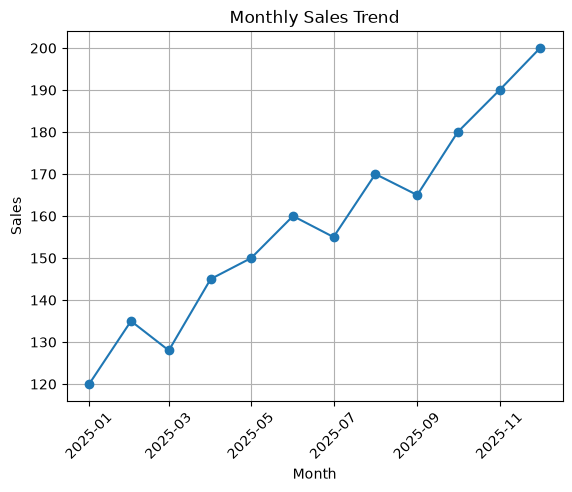

In [14]:
plt.plot(ts_df.index, ts_df["Sales"], marker="o")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [15]:
es_model = SimpleExpSmoothing(
    ts_df["Sales"]
).fit(optimized=True)

es_forecast = es_model.forecast(3)

print("Exponential Smoothing Forecast:")
print(es_forecast)

Exponential Smoothing Forecast:
2026-01-01    199.60495
2026-02-01    199.60495
2026-03-01    199.60495
Freq: MS, dtype: float64


c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
print("Next 3 Months Forecast:")
print(es_forecast)

Next 3 Months Forecast:
2026-01-01    199.60495
2026-02-01    199.60495
2026-03-01    199.60495
Freq: MS, dtype: float64


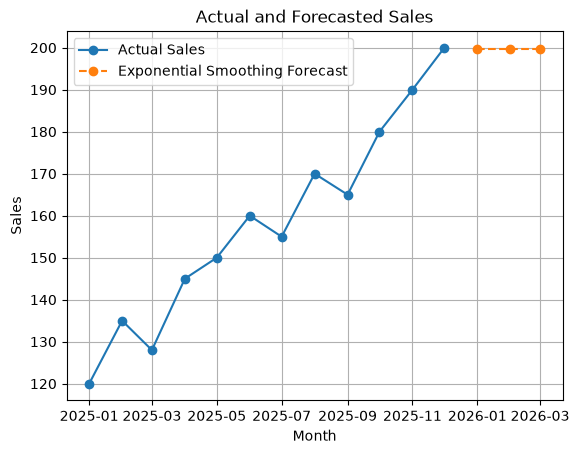

In [17]:
future_dates = pd.date_range(
    start=ts_df.index[-1] + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

plt.plot(ts_df.index, ts_df["Sales"],
         marker="o", label="Actual Sales")

plt.plot(future_dates, es_forecast.values,
         marker="o", linestyle="--",
         label="Exponential Smoothing Forecast")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual and Forecasted Sales")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
train = ts_df["Sales"].iloc[:-3]
test = ts_df["Sales"].iloc[-3:]

es_test_model = SimpleExpSmoothing(
    train
).fit(optimized=True)

es_test_forecast = es_test_model.forecast(3)

es_mse = mean_squared_error(test, es_test_forecast)

print("Exponential Smoothing MSE:", es_mse)

Exponential Smoothing MSE: 670.8826344294527


c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [19]:
arima_model = ARIMA(
    ts_df["Sales"],
    order=(1, 1, 1)
).fit()

print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   12
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -40.405
Date:                Sat, 03 Oct 2026   AIC                             86.811
Time:                        10:28:17   BIC                             88.005
Sample:                    01-01-2025   HQIC                            86.058
                         - 12-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0000      0.003   -296.271      0.000      -1.007      -0.993
ma.L1          0.9960      0.576      1.730      0.084      -0.133       2.125
sigma2        74.9840      0.008   9519.129      0.0

c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
arima_forecast = arima_model.forecast(steps=3)

print("ARIMA Forecast:")
print(arima_forecast)

ARIMA Forecast:
2026-01-01    193.259353
2026-02-01    199.999922
2026-03-01    193.259431
Freq: MS, Name: predicted_mean, dtype: float64


In [21]:
forecast_comparison = pd.DataFrame({
    "Exponential Smoothing": es_forecast.values,
    "ARIMA": arima_forecast.values
}, index=future_dates)

print(forecast_comparison)

            Exponential Smoothing       ARIMA
2026-01-01              199.60495  193.259353
2026-02-01              199.60495  199.999922
2026-03-01              199.60495  193.259431


In [22]:
# ARIMA trained on the same training period
arima_test_model = ARIMA(
    train,
    order=(1, 1, 1)
).fit()

arima_test_forecast = arima_test_model.forecast(steps=3)

# Calculate test errors
arima_mse = mean_squared_error(test, arima_test_forecast)

print("Exponential Smoothing MSE:", es_mse)
print("ARIMA MSE:", arima_mse)

Exponential Smoothing MSE: 670.8826344294527
ARIMA MSE: 470.80210263438283


c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\IT-32\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [23]:
if es_mse < arima_mse:
    print("Exponential Smoothing has lower forecasting error.")
elif arima_mse < es_mse:
    print("ARIMA has lower forecasting error.")
else:
    print("Both models have equal forecasting error.")

ARIMA has lower forecasting error.


In [ ]:
Step 29: Final conclusion
Conclusion: Time Series Analysis is used to study sales over time and forecast future sales. A line chart helps identify the overall trend. Exponential Smoothing and ARIMA are used to forecast the next three months. Their forecasting errors are calculated on the same test period and compared. The model with the lower test MSE has smaller squared prediction errors for that period.

SyntaxError: invalid syntax (1507811090.py, line 1)